<a href="https://colab.research.google.com/github/BekturMukhtarbekov/Acoustic-Extinguisher-Projesi/blob/main/BMT218_Proje_AcousticExtinguisher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ortam Hazırlama

In [1]:
# Inecek verisetin excel formatinda oldugu icin okunabilmesi icin
# gerekli kutuphanenin indirilmesi
!pip install openpyxl

In [39]:
# Gereken kutuphaneleri ekleyelim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import BayesianRidge, LinearRegression
from sklearn.metrics import roc_curve, auc

# 1. Veri Seti Hazirlik

## Veri Seti Yukleme

In [3]:
# Veri setinin indirilmesi
path = kagglehub.dataset_download("muratkokludataset/acoustic-extinguisher-fire-dataset")

# Inen klasorun icindeki dosyalarin goruntulenmesi
dosyalar = os.listdir(path)
print("Indirilen dosyalar:", dosyalar)


# Burada dosya yolunu olusturmus oluyoruz
tam_yol = os.path.join(
    path,
    "Acoustic_Extinguisher_Fire_Dataset",
    "Acoustic_Extinguisher_Fire_Dataset.xlsx"
)

# Verinin okunmasi
# Excel okumak için openpyxl gerekebilir: !pip install openpyxl
acous_ext = pd.read_excel(tam_yol)

print("\nVeri Başarıyla Yüklendi! İlk 5 Satır:")
print(acous_ext.head())

# Ek bilgilerin yazilmasi
print("\nInfo:",acous_ext.info())
print("\nDescribe:\n",acous_ext.describe())

100%|██████████| 621k/621k [00:00<00:00, 17.8MB/s]

Extracting files...
Indirilen dosyalar: ['Acoustic_Extinguisher_Fire_Dataset']



Veri Başarıyla Yüklendi! İlk 5 Satır:
   SIZE      FUEL  DISTANCE  DESIBEL  AIRFLOW  FREQUENCY  STATUS
0     1  gasoline        10       96      0.0         75       0
1     1  gasoline        10       96      0.0         72       1
2     1  gasoline        10       96      2.6         70       1
3     1  gasoline        10       96      3.2         68       1
4     1  gasoline        10      109      4.5         67       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB

Info: None

Describe:
                

Yukaridaki bilgilerden veri setinde FUEL sutununun object oldugunu gorebiliyoruz. Siniflandirmanin yapilabilmesi icin bu sutunun sayilara cevrilmesi gerek.

Ayrica normalizasyon icin secilecek yontemin belirlenmesinde iki yonteme basvurulmustur. Verinin %75'lik ceyreklik degerlerine ve asagida cizilen kutu grafiklere bakildiginda anlasiliyor ki aykiri degerler yok. Bundan dolayi Min-Max Normalizasyonu secilmistir. Aykiri degerlerin bulunmasi durumunda Standart Normalizasyon yontemine basvurulurdu.

Son olarak da bos hucrelerin olup olmadigini kontrol etmemiz gerekiyor.

## Veri Seti Kontrolu ve On Isleme

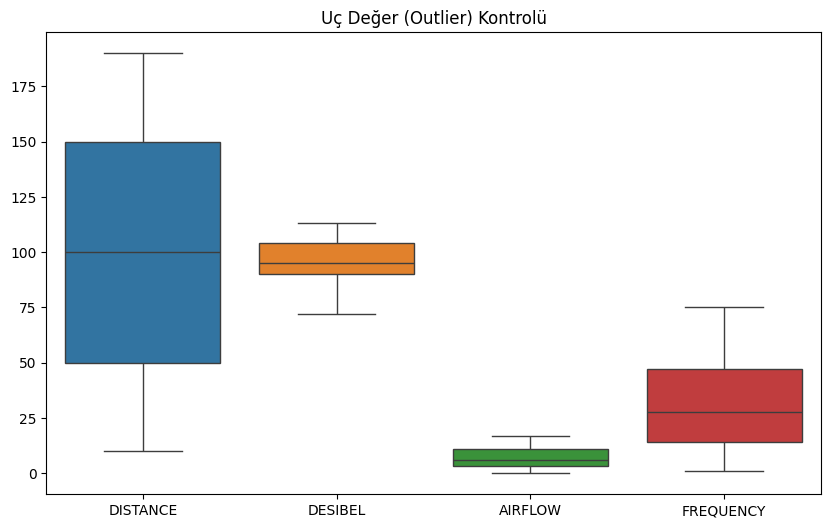

In [4]:
plt.figure(figsize=(10,6))
# Sayısal sütunların kutu grafiğini çizdirelim
sns.boxplot(data=acous_ext[['DISTANCE', 'DESIBEL', 'AIRFLOW', 'FREQUENCY']])
plt.title("Uç Değer (Outlier) Kontrolü")
plt.show()

In [5]:
# 1. Boş veri kontrolü
if acous_ext.isnull().sum().sum() == 0:
    print("Veride bos deger yok")
else:
    print("Bos deger var, temizlenmeli")

# 2. Metin verisi kontrolü
metin_sutunlari = acous_ext.select_dtypes(include=['object']).columns.tolist()
if len(metin_sutunlari) > 0:
    print(f"Ön işleme şart: {metin_sutunlari} sütunları sayıya çevrilmeli.")
    # Çözüm:
    le = LabelEncoder()
    for col in metin_sutunlari:
        acous_ext[col] = le.fit_transform(acous_ext[col])

        # Hangı yakıt turunun hangı sayıya eslestıgının ekrana yazdırılması
        print(f"=== '{col}' Sutun Sozlugu ===")
        for indeks, gercek_isim in enumerate(le.classes_):
            print(f"{gercek_isim}\t{indeks}")
    print("Metin verileri sayiya donusturuldu.")

# 3. Ölçeklendirme (Scaling) ihtiyacı kontrolü
print("\nVeri araliklarinin incelenmesi")
print(acous_ext.describe().loc[['min', 'max']])

Veride bos deger yok
Ön işleme şart: ['FUEL'] sütunları sayıya çevrilmeli.
=== 'FUEL' Sutun Sozlugu ===
gasoline	0
kerosene	1
lpg	2
thinner	3
Metin verileri sayiya donusturuldu.

Veri araliklarinin incelenmesi
     SIZE  FUEL  DISTANCE  DESIBEL  AIRFLOW  FREQUENCY  STATUS
min   1.0   0.0      10.0     72.0      0.0        1.0     0.0
max   7.0   3.0     190.0    113.0     17.0       75.0     1.0


## Veri Setini Bolme

Veri setinin egitim ve hedef olarak bolunmesi

In [6]:
# 'STATUS' hedef değişken (y), diğer her şey özellik (X)
X = acous_ext.drop('STATUS', axis=1)
y = acous_ext['STATUS']

'''
Normalizasyona "ihtiyac duyan" modellerini (KNN, SVM vb.) hem normalizasyon
isleminden gecen veri hem de ham veri ile egiterek en son karsilastirip
normalizasyonun onemini vurgulamak icin kullanilacaktir.
'''
# Normalizasyona ihtiyac duyan modeller icin verinin on islenmesi
scaler = MinMaxScaler()
# Scaler, verimizi numpy matrisine donusturecektir.
# pandas dataframe'i olarak kullanabilmemiz icin donusturulmesi gerekecektir.
X_scaled_dizi = scaler.fit_transform(X)
Xsc = pd.DataFrame(X_scaled_dizi, columns = X.columns)

# Veri setinin %80 egitim %20 test olarak bolunmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Xsc_train, Xsc_test, y_train, y_test = train_test_split(Xsc, y, test_size=0.2, random_state=42)

# 2. Model Olusturma

## KNN Algoritamsı

### Model Eğitimi ve Tahmin

#### Ham Veri

In [7]:
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_4 = KNeighborsClassifier(n_neighbors=4)
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_6 = KNeighborsClassifier(n_neighbors=6)
knn_7 = KNeighborsClassifier(n_neighbors=7)
knn_8 = KNeighborsClassifier(n_neighbors=8)
knn_9 = KNeighborsClassifier(n_neighbors=9)

knn_3.fit(X_train, y_train)
knn_4.fit(X_train, y_train)
knn_5.fit(X_train, y_train)
knn_6.fit(X_train, y_train)
knn_7.fit(X_train, y_train)
knn_8.fit(X_train, y_train)
knn_9.fit(X_train, y_train)

y_pred_3 = knn_3.predict(X_test)
y_pred_4 = knn_4.predict(X_test)
y_pred_5 = knn_5.predict(X_test)
y_pred_6 = knn_6.predict(X_test)
y_pred_7 = knn_7.predict(X_test)
y_pred_8 = knn_8.predict(X_test)
y_pred_9 = knn_9.predict(X_test)

y_proba_3 = knn_3.predict_proba(X_test)
y_proba_4 = knn_4.predict_proba(X_test)
y_proba_5 = knn_5.predict_proba(X_test)
y_proba_6 = knn_6.predict_proba(X_test)
y_proba_7 = knn_7.predict_proba(X_test)
y_proba_8 = knn_8.predict_proba(X_test)
y_proba_9 = knn_9.predict_proba(X_test)

#### Normalize edilmis veri

In [8]:
knn_3_sc = KNeighborsClassifier(n_neighbors=3)
knn_4_sc = KNeighborsClassifier(n_neighbors=4)
knn_5_sc = KNeighborsClassifier(n_neighbors=5)
knn_6_sc = KNeighborsClassifier(n_neighbors=6)
knn_7_sc = KNeighborsClassifier(n_neighbors=7)
knn_8_sc = KNeighborsClassifier(n_neighbors=8)
knn_9_sc = KNeighborsClassifier(n_neighbors=9)

knn_3_sc.fit(Xsc_train, y_train)
knn_4_sc.fit(Xsc_train, y_train)
knn_5_sc.fit(Xsc_train, y_train)
knn_6_sc.fit(Xsc_train, y_train)
knn_7_sc.fit(Xsc_train, y_train)
knn_8_sc.fit(Xsc_train, y_train)
knn_9_sc.fit(Xsc_train, y_train)

y_pred_3_sc = knn_3_sc.predict(Xsc_test)
y_pred_4_sc = knn_4_sc.predict(Xsc_test)
y_pred_5_sc = knn_5_sc.predict(Xsc_test)
y_pred_6_sc = knn_6_sc.predict(Xsc_test)
y_pred_7_sc = knn_7_sc.predict(Xsc_test)
y_pred_8_sc = knn_8_sc.predict(Xsc_test)
y_pred_9_sc = knn_9_sc.predict(Xsc_test)

y_proba_3_sc = knn_3_sc.predict_proba(Xsc_test)
y_proba_4_sc = knn_4_sc.predict_proba(Xsc_test)
y_proba_5_sc = knn_5_sc.predict_proba(Xsc_test)
y_proba_6_sc = knn_6_sc.predict_proba(Xsc_test)
y_proba_7_sc = knn_7_sc.predict_proba(Xsc_test)
y_proba_8_sc = knn_8_sc.predict_proba(Xsc_test)
y_proba_9_sc = knn_9_sc.predict_proba(Xsc_test)

### Değerlendirme

In [9]:
# Ham veri ile egitilmis model sonuclari
print("===Ham Veri Ile Egitilen Model Sonuclari===\n")
print("Confusion Matrix for n_neighbors=3:")
print(confusion_matrix(y_test, y_pred_3))
print(classification_report(y_test, y_pred_3,digits=4))

print("\nConfusion Matrix for n_neighbors=4:")
print(confusion_matrix(y_test, y_pred_4))
print(classification_report(y_test, y_pred_4,digits=4))

print("\nConfusion Matrix for n_neighbors=5:")
print(confusion_matrix(y_test, y_pred_5))
print(classification_report(y_test, y_pred_5,digits=4))

print("\nConfusion Matrix for n_neighbors=6:")
print(confusion_matrix(y_test, y_pred_6))
print(classification_report(y_test, y_pred_6,digits=4))

print("\nConfusion Matrix for n_neighbors=7:")
print(confusion_matrix(y_test, y_pred_7))
print(classification_report(y_test, y_pred_7,digits=4))

print("\nConfusion Matrix for n_neighbors=8:")
print(confusion_matrix(y_test, y_pred_8))
print(classification_report(y_test, y_pred_8,digits=4))

print("\nConfusion Matrix for n_neighbors=9:")
print(confusion_matrix(y_test, y_pred_9))
print(classification_report(y_test, y_pred_9,digits=4))


# Normalize veri ile egitilmis model sonuclari
print("\n\n===Normalize Veri Ile Egitilen Model Sonuclari===\n")
print("Confusion Matrix for n_neighbors=3:")
print(confusion_matrix(y_test, y_pred_3_sc))
print(classification_report(y_test, y_pred_3_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=4:")
print(confusion_matrix(y_test, y_pred_4_sc))
print(classification_report(y_test, y_pred_4_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=5:")
print(confusion_matrix(y_test, y_pred_5_sc))
print(classification_report(y_test, y_pred_5_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=6:")
print(confusion_matrix(y_test, y_pred_6_sc))
print(classification_report(y_test, y_pred_6_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=7:")
print(confusion_matrix(y_test, y_pred_7_sc))
print(classification_report(y_test, y_pred_7_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=8:")
print(confusion_matrix(y_test, y_pred_8_sc))
print(classification_report(y_test, y_pred_8_sc,digits=4))

print("\nConfusion Matrix for n_neighbors=9:")
print(confusion_matrix(y_test, y_pred_9_sc))
print(classification_report(y_test, y_pred_9_sc,digits=4))

===Ham Veri Ile Egitilen Model Sonuclari===

Confusion Matrix for n_neighbors=3:
[[1586  128]
 [ 153 1622]]
              precision    recall  f1-score   support

           0     0.9120    0.9253    0.9186      1714
           1     0.9269    0.9138    0.9203      1775

    accuracy                         0.9195      3489
   macro avg     0.9194    0.9196    0.9195      3489
weighted avg     0.9196    0.9195    0.9195      3489


Confusion Matrix for n_neighbors=4:
[[1641   73]
 [ 238 1537]]
              precision    recall  f1-score   support

           0     0.8733    0.9574    0.9134      1714
           1     0.9547    0.8659    0.9081      1775

    accuracy                         0.9109      3489
   macro avg     0.9140    0.9117    0.9108      3489
weighted avg     0.9147    0.9109    0.9107      3489


Confusion Matrix for n_neighbors=5:
[[1598  116]
 [ 149 1626]]
              precision    recall  f1-score   support

           0     0.9147    0.9323    0.9234      1714
 

**KNN algoritmasi degerler/noktalar arasi mesafeye gore tahmin ve siniflandirma yapar. Bu sebeple ham veri ile egitilen modeller ile normalize veri ile egitilen modellerin dogruluklari arasinda yaklasik 0.04'luk bir fark gozlemlenmistir.**

## SVM (Support Vector Machine)

SVM icin veri setinin ayrilip ayri degiskenlere atanmasi.

In [10]:
X_svm = acous_ext.drop('STATUS', axis=1)
y_svm = acous_ext['STATUS']
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(X_svm, y_svm, test_size = 0.2, random_state = 42)

# Frekans degerleri cok yuksek sayi olabilirken Mesafe degerleri cok kucuk degerlere sahip olabiliyor.
# Verinin olceklenirilmemesi halinde buyuk sayilar kucukleri ezer ve modelin performansi dusmus olur
# bunu onlemek icin StandardScaler kullanilir
scaler = StandardScaler()
X_svm_train_scaled = scaler.fit_transform(X_svm_train)
X_svm_test_scaled = scaler.transform(X_svm_test)

Ayirdigimiz veri setiyle farkli C ve Gamma degerleriyle modellerin egitimi.

In [11]:
# Lineer icin C=1.0    RBF icin C=1.0, gamma=0.1
model_lin = SVC(kernel = 'linear', C=1.0, probability=True)
model_lin.fit(X_svm_train_scaled, y_svm_train)
y_score_svm_lin = model_lin.predict_proba(X_svm_test_scaled)[:,1]

model_rbf = SVC(kernel = 'rbf', C=1.0, gamma=0.1, probability=True)
model_rbf.fit(X_svm_train_scaled, y_svm_train)
y_score_svm_rbf = model_rbf.predict_proba(X_svm_test_scaled)[:,1]

y_pred_svm_lin = model_lin.predict(X_svm_test_scaled)
y_pred_svm_rbf = model_rbf.predict(X_svm_test_scaled)

print("\nLineer SVM: Verilerin Dogrusal ayrilmasi\n")
print(confusion_matrix(y_svm_test, y_pred_svm_lin))
print(classification_report(y_svm_test, y_pred_svm_lin,digits=4))
print("\nRBF SVM\n")
print(confusion_matrix(y_svm_test, y_pred_svm_rbf))
print(classification_report(y_svm_test, y_pred_svm_rbf,digits=4))


Lineer SVM: Verilerin Dogrusal ayrilmasi

[[1543  171]
 [ 246 1529]]
              precision    recall  f1-score   support

           0     0.8625    0.9002    0.8810      1714
           1     0.8994    0.8614    0.8800      1775

    accuracy                         0.8805      3489
   macro avg     0.8810    0.8808    0.8805      3489
weighted avg     0.8813    0.8805    0.8805      3489


RBF SVM

[[1613  101]
 [ 127 1648]]
              precision    recall  f1-score   support

           0     0.9270    0.9411    0.9340      1714
           1     0.9423    0.9285    0.9353      1775

    accuracy                         0.9347      3489
   macro avg     0.9346    0.9348    0.9346      3489
weighted avg     0.9348    0.9347    0.9347      3489



In [12]:
# Lineer icin C=100    RBF icin C=10, gamma=0.01
model_lin1 = SVC(kernel = 'linear', C=100.0, probability=True)
model_lin1.fit(X_svm_train_scaled, y_svm_train)

model_rbf1 = SVC(kernel = 'rbf', C=10.0, gamma=0.01, probability=True)
model_rbf1.fit(X_svm_train_scaled, y_svm_train)

y_pred_svm_lin1 = model_lin1.predict(X_svm_test_scaled)
y_pred_svm_rbf1 = model_rbf1.predict(X_svm_test_scaled)

print("\nLineer SVM: Verilerin Dogrusal ayrilmasi\n")
print(confusion_matrix(y_svm_test, y_pred_svm_lin1))
print(classification_report(y_svm_test, y_pred_svm_lin1,digits=4))
print("\nRBF SVM\n")
print(confusion_matrix(y_svm_test, y_pred_svm_rbf1))
print(classification_report(y_svm_test, y_pred_svm_rbf1,digits=4))


Lineer SVM: Verilerin Dogrusal ayrilmasi

[[1543  171]
 [ 246 1529]]
              precision    recall  f1-score   support

           0     0.8625    0.9002    0.8810      1714
           1     0.8994    0.8614    0.8800      1775

    accuracy                         0.8805      3489
   macro avg     0.8810    0.8808    0.8805      3489
weighted avg     0.8813    0.8805    0.8805      3489


RBF SVM

[[1586  128]
 [ 166 1609]]
              precision    recall  f1-score   support

           0     0.9053    0.9253    0.9152      1714
           1     0.9263    0.9065    0.9163      1775

    accuracy                         0.9157      3489
   macro avg     0.9158    0.9159    0.9157      3489
weighted avg     0.9160    0.9157    0.9157      3489



In [13]:
# Lineer icin C=10    RBF icin C=100, gamma=0.01
model_lin2 = SVC(kernel = 'linear', C=10.0, probability=True)
model_lin2.fit(X_svm_train_scaled, y_svm_train)

model_rbf2 = SVC(kernel = 'rbf', C=100, gamma=0.01, probability=True)
model_rbf2.fit(X_svm_train_scaled, y_svm_train)

y_pred_svm_lin2 = model_lin2.predict(X_svm_test_scaled)
y_pred_svm_rbf2 = model_rbf2.predict(X_svm_test_scaled)

print("\nLineer SVM: Verilerin Dogrusal ayrilmasi\n")
print(confusion_matrix(y_svm_test, y_pred_svm_lin2))
print(classification_report(y_svm_test, y_pred_svm_lin2,digits=4))
print("\nRBF SVM\n")
print(confusion_matrix(y_svm_test, y_pred_svm_rbf2))
print(classification_report(y_svm_test, y_pred_svm_rbf2,digits=4))


Lineer SVM: Verilerin Dogrusal ayrilmasi

[[1543  171]
 [ 246 1529]]
              precision    recall  f1-score   support

           0     0.8625    0.9002    0.8810      1714
           1     0.8994    0.8614    0.8800      1775

    accuracy                         0.8805      3489
   macro avg     0.8810    0.8808    0.8805      3489
weighted avg     0.8813    0.8805    0.8805      3489


RBF SVM

[[1607  107]
 [ 147 1628]]
              precision    recall  f1-score   support

           0     0.9162    0.9376    0.9268      1714
           1     0.9383    0.9172    0.9276      1775

    accuracy                         0.9272      3489
   macro avg     0.9273    0.9274    0.9272      3489
weighted avg     0.9275    0.9272    0.9272      3489



**Egitimlerin sonucu modelin cekirdek tipi lineer oldugu zaman C degerinin degismesi dogruluk degerini etkilemiyor. RBF cekirdek tipi icin ise en yuksek dogruluk C=1.0 ve gamma=0.1 degerleri icin en yuksek olarak hesaplaniyor.**

## Regresyon

In [40]:
#Lineer Regresyon modeli.

#Modelin olusturulmasi
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

#Tahminlerin yapilmasi
y_pred_linear = linear_model.predict(X_test)

#Metriklerin hesaplanmasi
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)


print("Lineer Regresyon")
print("MSE:", mse_linear)
print("R2:", r2_linear)

Lineer Regresyon
MSE: 0.09378795428165786
R2: 0.6247334738563646


## Naive Bayes

In [15]:
from sklearn.linear_model import LogisticRegression

# Modeli kur ve eğit
log_model = LogisticRegression()
log_model.fit(Xsc_train, y_train)

# Tahmin yap (Logistic Regression otomatik olarak 0 ve 1 üretir!)
y_pred_log = log_model.predict(Xsc_test)

# Ve mutlu son:
print(classification_report(y_test, y_pred_log))#Naive(Basit Bayes) Siniflandirma modeli
naive_bayes=GaussianNB()#modeli olustur
naive_bayes.fit(X_train,y_train)#modeli egit
y_pred_nbayes=naive_bayes.predict(X_test)#Tahmin yapıcak test kumesı ile
#Sonucları yazdırma
y_pred_nbayes_proba=naive_bayes.predict_proba(X_test)
print("Naive Bayes Siniflandrirma")
print("Naive Bayes Doğruluk:", accuracy_score(y_test, y_pred_nbayes))
print("Classification Report:\n", classification_report(y_test, y_pred_nbayes,digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nbayes))

Naive Bayes Siniflandrirma
Naive Bayes Doğruluk: 0.8730295213528232
Classification Report:
               precision    recall  f1-score   support

           0     0.8505    0.8996    0.8744      1714
           1     0.8974    0.8473    0.8716      1775

    accuracy                         0.8730      3489
   macro avg     0.8739    0.8735    0.8730      3489
weighted avg     0.8744    0.8730    0.8730      3489

Confusion Matrix:
 [[1542  172]
 [ 271 1504]]


## Karar Ağaçları

[[1577  137]
 [ 178 1597]]
              precision    recall  f1-score   support

           0     0.8986    0.9201    0.9092      1714
           1     0.9210    0.8997    0.9102      1775

    accuracy                         0.9097      3489
   macro avg     0.9098    0.9099    0.9097      3489
weighted avg     0.9100    0.9097    0.9097      3489



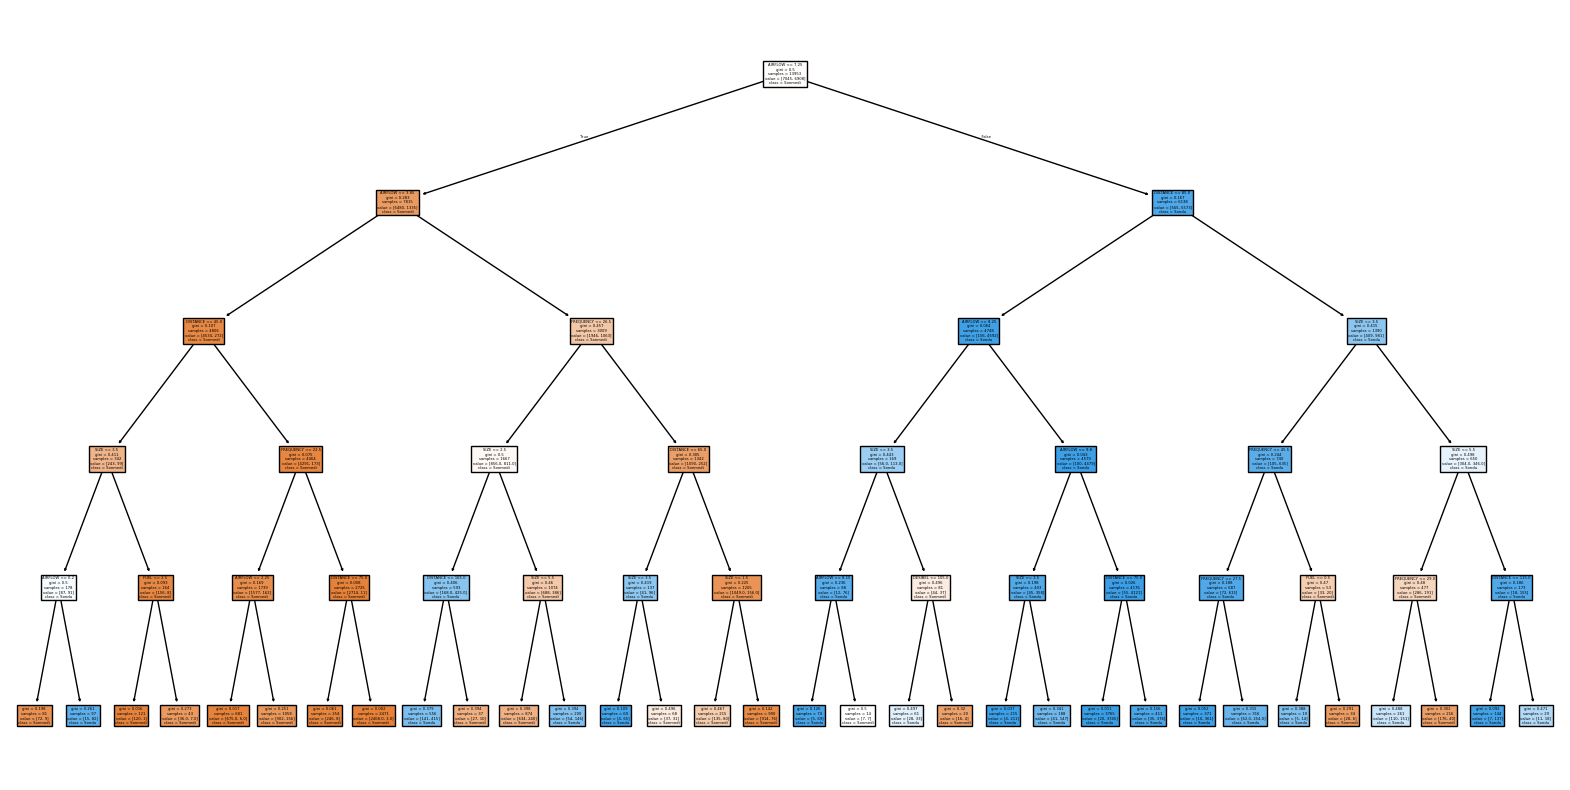

In [16]:
#Karar agacı olusturuldu.
#Algoritma olarak gini kullanıldı ve derinik 5 ayarlandı.
#hem tahmin sonuclar ve dogruluklar hesaplandı
#hem de karar ağacının şeması
tree_model=DecisionTreeClassifier(criterion="gini",max_depth=5)
tree_model.fit(X_train,y_train)
y_treepred=tree_model.predict(X_test)
y_pred_karar_proba=tree_model.predict_proba(X_test)
print(confusion_matrix(y_test, y_treepred))
print(classification_report(y_test, y_treepred,digits=4))
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['Sonmedi', 'Sondu']
          )
plt.show()

[[1640   74]
 [  76 1699]]
              precision    recall  f1-score   support

           0     0.9557    0.9568    0.9563      1714
           1     0.9583    0.9572    0.9577      1775

    accuracy                         0.9570      3489
   macro avg     0.9570    0.9570    0.9570      3489
weighted avg     0.9570    0.9570    0.9570      3489



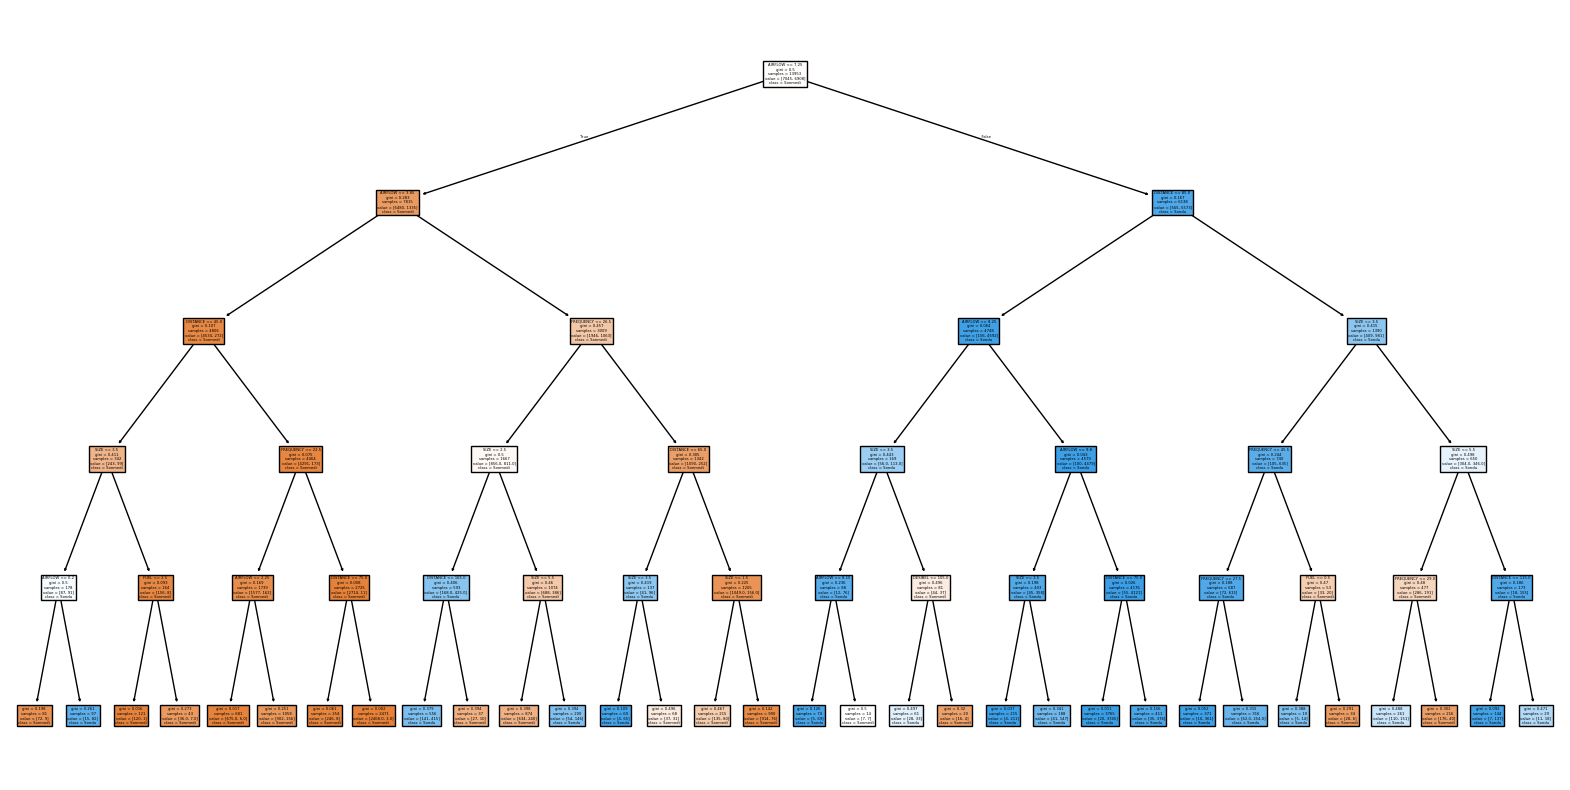

In [17]:
#derinlik 10 yapıldı daha ıyı sonuc verdıgı goruldu.
tree_model2=DecisionTreeClassifier(criterion="gini",max_depth=10)
tree_model2.fit(X_train,y_train)
y_treepred2=tree_model2.predict(X_test)
y_pred_karar_proba2=tree_model2.predict_proba(X_test)
print(confusion_matrix(y_test, y_treepred2))
print(classification_report(y_test, y_treepred2,digits=4))
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['Sonmedi', 'Sondu']
          )
plt.show()

[[1651   63]
 [  62 1713]]
              precision    recall  f1-score   support

           0     0.9638    0.9632    0.9635      1714
           1     0.9645    0.9651    0.9648      1775

    accuracy                         0.9642      3489
   macro avg     0.9642    0.9642    0.9642      3489
weighted avg     0.9642    0.9642    0.9642      3489



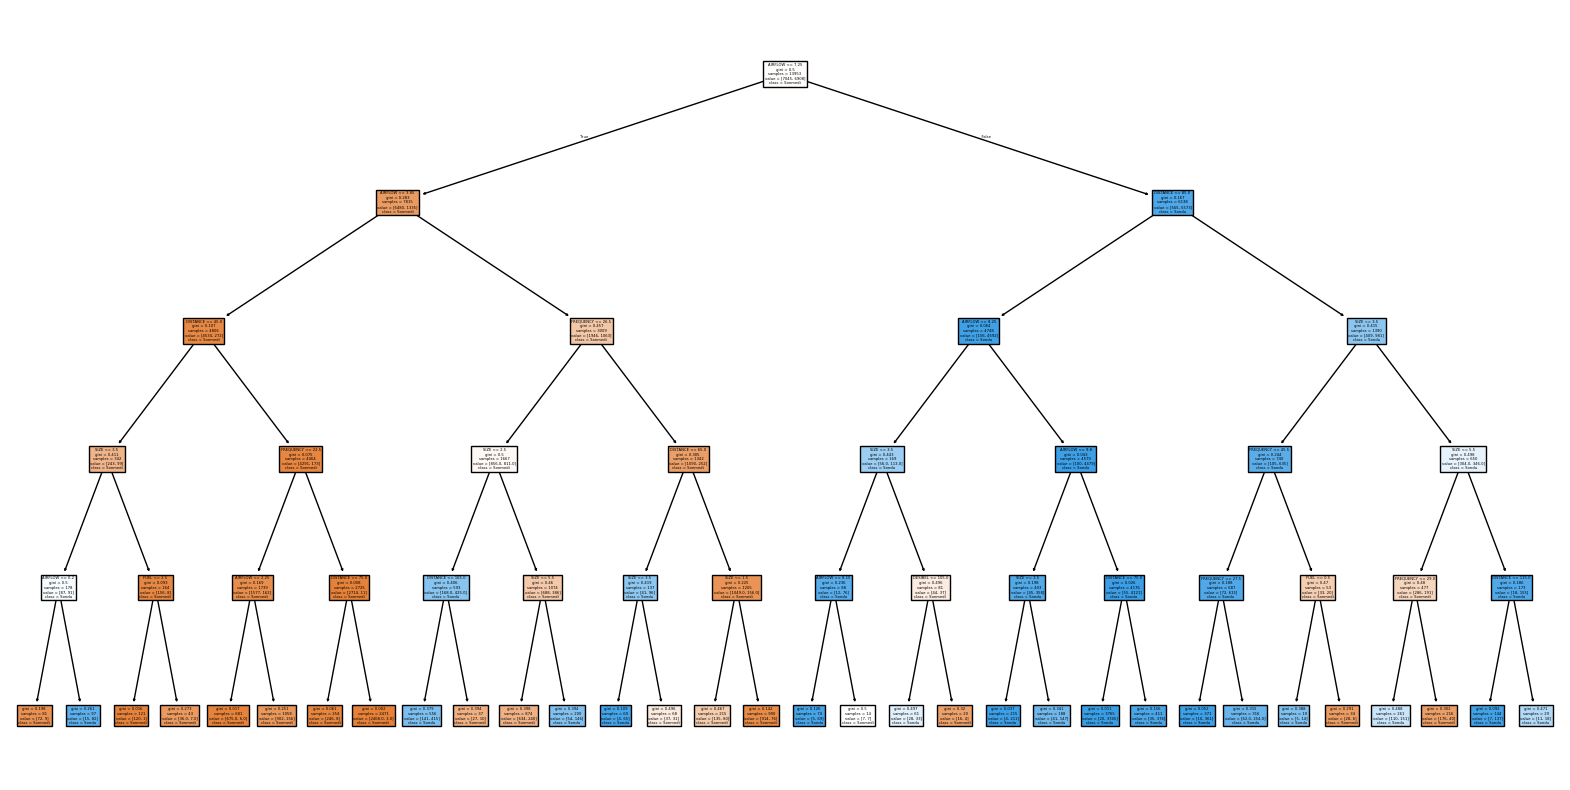

In [18]:
# en dogru sonucu derınlık 15 olunca verıyor.
tree_model3=DecisionTreeClassifier(criterion="gini",max_depth=15)
tree_model3.fit(X_train,y_train)
y_treepred3=tree_model3.predict(X_test)
y_pred_karar_proba3=tree_model3.predict_proba(X_test)
print(confusion_matrix(y_test, y_treepred3))
print(classification_report(y_test, y_treepred3,digits=4))
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['Sonmedi', 'Sondu']
          )
plt.show()

In [19]:
tree_model4=DecisionTreeClassifier(criterion="gini",max_depth=20)
tree_model4.fit(X_train,y_train)
y_treepred4=tree_model4.predict(X_test)
y_pred_karar_proba4=tree_model4.predict_proba(X_test)
print(confusion_matrix(y_test, y_treepred4))
print(classification_report(y_test, y_treepred4,digits=4))

[[1654   60]
 [  62 1713]]
              precision    recall  f1-score   support

           0     0.9639    0.9650    0.9644      1714
           1     0.9662    0.9651    0.9656      1775

    accuracy                         0.9650      3489
   macro avg     0.9650    0.9650    0.9650      3489
weighted avg     0.9650    0.9650    0.9650      3489



## Random Forest

In [20]:
# Hiperparametre araliginin belirlenmesi
param_grid = {
    'n_estimators':[10,20,30,50],
    'max_depth':[5,10,None]
}

# Model nesnesi
rd = RandomForestClassifier(random_state=42)

# GridSearchCV kurulumu
grid_search = GridSearchCV(
    estimator=rd,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred_rf = best_model.predict(X_test)
y_proba_rf = best_model.predict_proba(X_test)

print("En iyi parametreler:", grid_search.best_params_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
En iyi parametreler: {'max_depth': None, 'n_estimators': 50}

Confusion Matrix:
[[1654   60]
 [  55 1720]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9678    0.9650    0.9664      1714
           1     0.9663    0.9690    0.9677      1775

    accuracy                         0.9670      3489
   macro avg     0.9671    0.9670    0.9670      3489
weighted avg     0.9670    0.9670    0.9670      3489



# 3. Grafikler

## Bar Grafigi ile Dogruluk Karsilastirilmasi

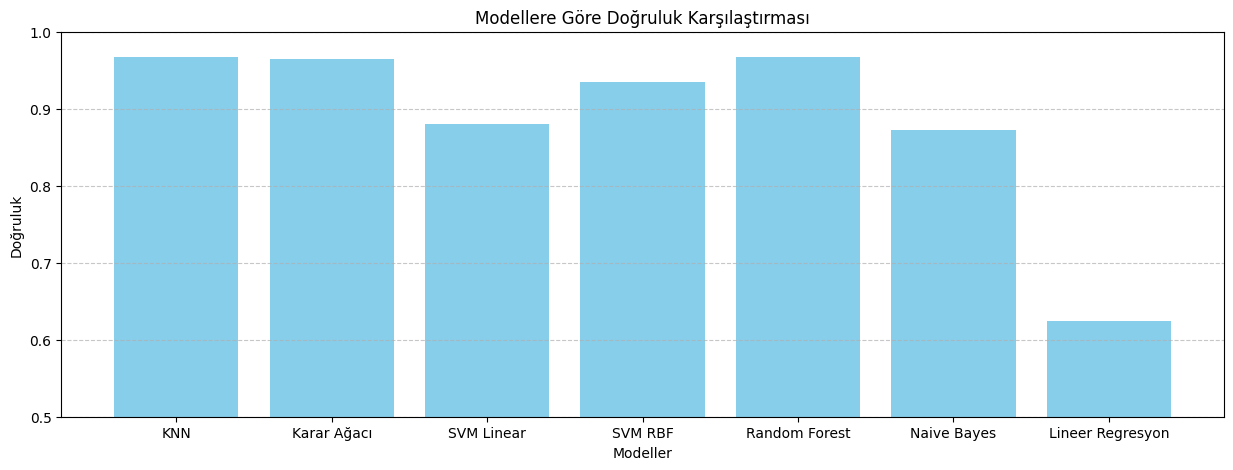

In [41]:
#Bar grafikleri icin gerekli olan listelerin olusturulmasi
model_names = ['KNN', 'Karar Ağacı', 'SVM Linear', 'SVM RBF', 'Random Forest','Naive Bayes','Lineer Regresyon']
accuracy_scores = [0.9668, 0.9650, 0.8805, 0.9347, 0.9670, 0.8730, 0.6247]

#Bar grafiginin olusturulmasi
plt.figure(figsize=(15, 5))
plt.bar(model_names, accuracy_scores, color='skyblue')
plt.ylim(0.5, 1)
plt.title('Modellere Göre Doğruluk Karşılaştırması')
plt.xlabel('Modeller')
plt.ylabel('Doğruluk')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## ROC Egrileri

### KNN

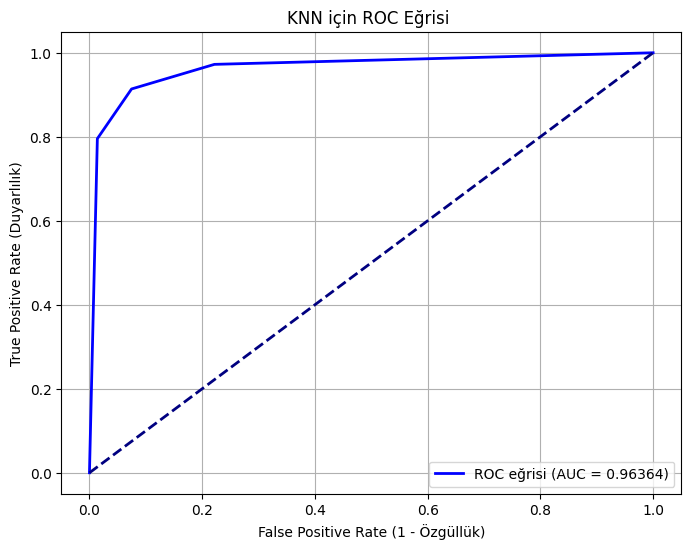

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_3[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC eğrisi (AUC = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # rastgele tahmin çizgisi
plt.xlabel('False Positive Rate (1 - Özgüllük)')
plt.ylabel('True Positive Rate (Duyarlılık)')
plt.title('KNN için ROC Eğrisi ')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Random Forest

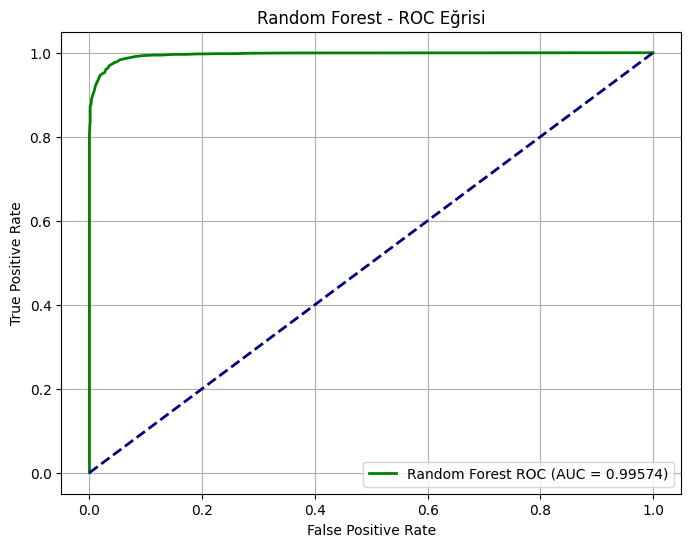

In [24]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='Random Forest ROC (AUC = %0.5f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Bayes

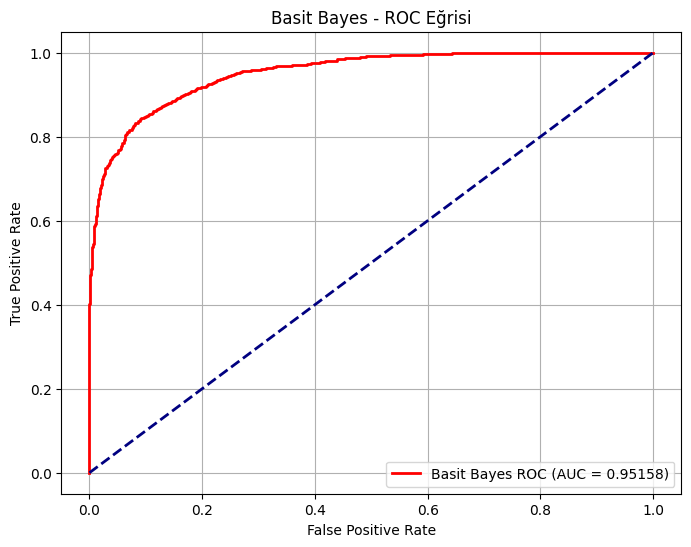

In [25]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_nbayes_proba[:, 1])
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label='Basit Bayes ROC (AUC = %0.5f)' % roc_auc_nb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Basit Bayes - ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Linear SVM

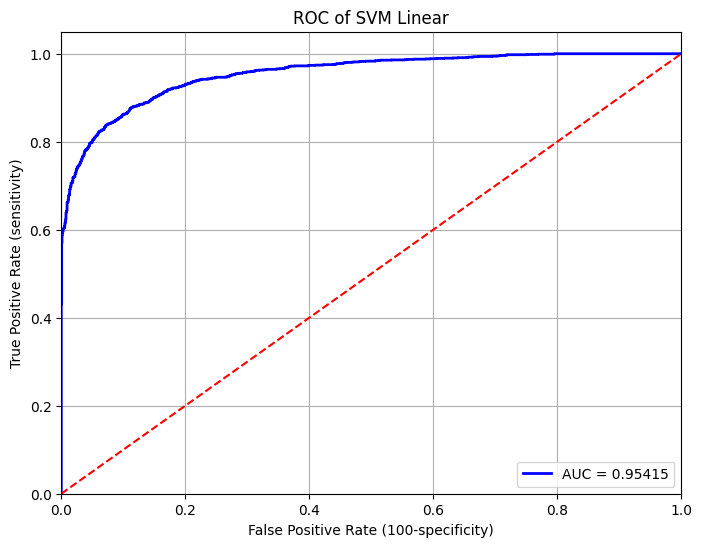

In [26]:
fpr_svm_lin, tpr_svm_lin, _ = roc_curve(y_svm_test, y_score_svm_lin)
roc_auc_svm_lin = auc(fpr_svm_lin, tpr_svm_lin)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm_lin, tpr_svm_lin, color='blue', lw=2, label='AUC = %0.5f' % roc_auc_svm_lin)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (100-specificity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC of SVM Linear')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### RBF SVM

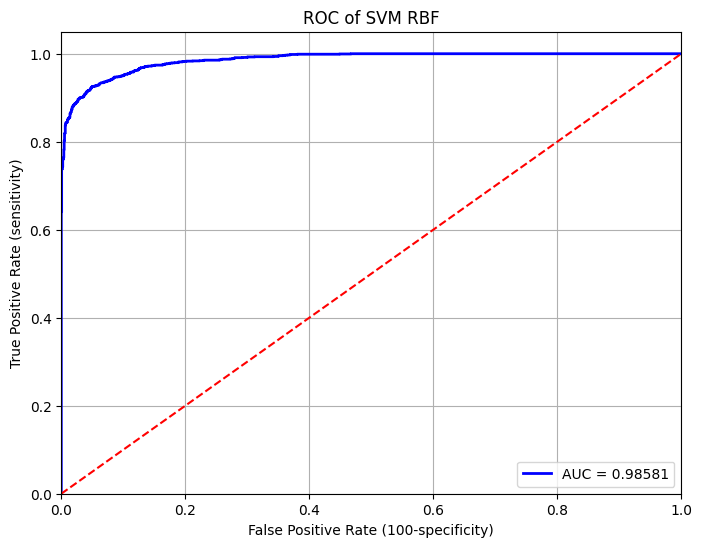

In [27]:
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_svm_test, y_score_svm_rbf)
roc_auc_svm_rbf = auc(fpr_svm_rbf, tpr_svm_rbf)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='blue', lw=2, label='AUC = %0.5f' % roc_auc_svm_rbf)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (100-specificity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC of SVM RBF')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Karar Agaci

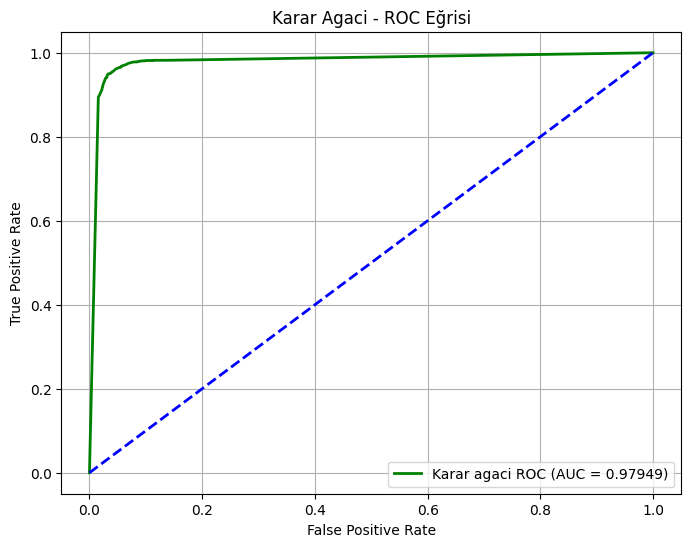

In [28]:
fpr_ka, tpr_ka, _ = roc_curve(y_test, y_pred_karar_proba2[:, 1])
roc_auc_ka = auc(fpr_ka, tpr_ka)
plt.figure(figsize=(8, 6))
plt.plot(fpr_ka, tpr_ka, color='green', lw=2, label='Karar agaci ROC (AUC = %0.5f)' % roc_auc_ka)
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Karar Agaci - ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()